# 04 · Decision Trees vs. Random Forests, Explained Visually

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/04-decision-trees-and-random-forests/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Make up 500 patients

In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(367)
n = 500
df = pd.DataFrame({
    "temperature": rng.normal(37.7, 0.8, n).round(1),  # body temperature in °C
    "fatigue": rng.integers(1, 11, n),                 # tiredness from 1 to 10
    "cough": rng.integers(0, 2, n),                    # 1 = yes, 0 = no
    "aches": rng.integers(0, 2, n),
    "chills": rng.integers(0, 2, n),
    "sore_throat": rng.integers(0, 2, n),
})

# The hidden rule: fever counts most, then a cough, then everything else
points = (2 * (df.temperature - 36) + 1.5 * df.cough + df.aches + df.chills
          + df.sore_throat + df.fatigue / 4)
df["flu"] = (points > 7).astype(int)

# Real records contain mistakes, so flip 12% of the diagnoses at random
wrong = rng.random(n) < 0.12
df.loc[wrong, "flu"] = 1 - df.loc[wrong, "flu"]

print(df.head())
print("patients with flu:", df["flu"].sum(), "of", n)
#    temperature  fatigue  cough  aches  chills  sore_throat  flu
# 0         38.2        7      0      0       0            1    1
# 1         37.4        2      0      0       0            0    0
# 2         39.7        8      1      0       1            0    1
# 3         37.8        1      1      1       0            1    1
# 4         38.4        6      1      0       0            0    1
# patients with flu: 250 of 500

   temperature  fatigue  cough  aches  chills  sore_throat  flu
0         38.2        7      0      0       0            1    1
1         37.4        2      0      0       0            0    0
2         39.7        8      1      0       1            0    1
3         37.8        1      1      1       0            1    1
4         38.4        6      1      0       0            0    1
patients with flu: 250 of 500


- Each row is a patient with six features: body temperature, a tiredness score from 1 to 10, and four yes/no symptoms stored as 1 or 0. The last column, `flu`, is the label to predict.
- The hidden rule adds up points and calls it flu above 7. Knowing the true rule lets us check what the models learn; with real data you never get to see it.
- Flipping 12% of the labels mimics real records, where some diagnoses are simply wrong. Keep those wrong labels in mind: an unlimited tree will memorize them.

### Step 2 · Train a small tree and read its questions

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text

X = df.drop(columns="flu")
y = df["flu"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

small_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
small_tree.fit(X_train, y_train)

print("test accuracy:", round(small_tree.score(X_test, y_test), 2))
print(export_text(small_tree, feature_names=list(X.columns), class_names=["no flu", "flu"]))
# test accuracy: 0.67
# |--- temperature <= 37.75
# |   |--- fatigue <= 8.50
# |   |   |--- class: no flu
# |   |--- fatigue >  8.50
# |   |   |--- class: flu
# |--- temperature >  37.75
# |   |--- fatigue <= 2.50
# |   |   |--- class: no flu
# |   |--- fatigue >  2.50
# |   |   |--- class: flu

test accuracy: 0.67
|--- temperature <= 37.75
|   |--- fatigue <= 8.50
|   |   |--- class: no flu
|   |--- fatigue >  8.50
|   |   |--- class: flu
|--- temperature >  37.75
|   |--- fatigue <= 2.50
|   |   |--- class: no flu
|   |--- fatigue >  2.50
|   |   |--- class: flu



- `max_depth=2` allows at most two questions in a row, so this tree has three questions and four leaves. It's the same tree as the flowchart at the top of this lesson.
- `export_text` prints the tree as indented rules. Read `temperature <= 37.75` as "no" to *"Is the temperature above 37.75 °C?"*, and each `class:` line as a leaf's answer.
- The tree found its own fever line at 37.75 °C, close to the 38 °C that doctors use, just by searching for the purest split.
- `stratify=y` keeps the same flu/no-flu mix in the training and test sets, and `random_state=42` makes the tree break ties the same way every run. For classifiers, `model.score(X, y)` is accuracy: three questions already get 67% of new patients right.

### Step 3 · Draw the tree

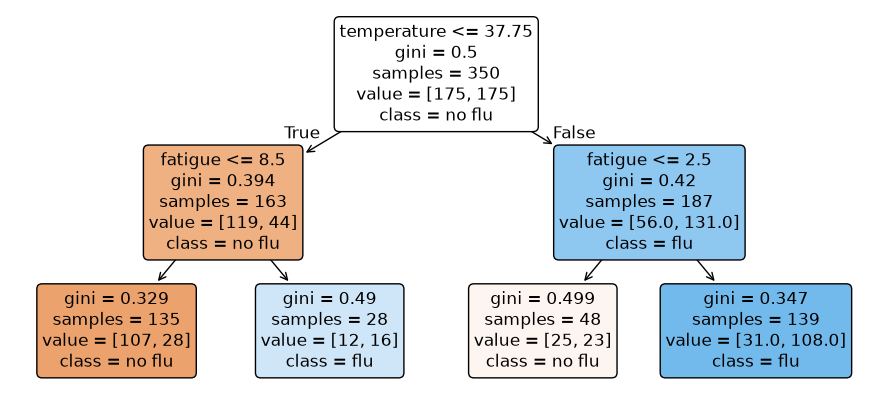

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(11, 5))
plot_tree(small_tree, feature_names=list(X.columns), class_names=["no flu", "flu"],
          filled=True, rounded=True)
plt.show()

- Each box shows its question, then **gini** (how mixed the patients who reached it are), **samples** (how many training patients reached it), **value** (how many of them had no flu and flu) and **class** (the majority answer). The arrows marked True and False tell you whether the box's condition, like `temperature <= 37.75`, holds.
- The root holds all 350 training patients, half with flu: a Gini of 0.5, the most mixed possible. The two big leaves are much purer (0.33 and 0.35), while two small ones stay almost 50/50. A split lowers the *average* impurity, not every group's.
- With `filled=True`, the color shows each box's majority class, and a stronger color means a purer group. scikit-learn picks its own colors, so they don't match this lesson's diagrams.

### Step 4 · Let the tree grow: overfitting in action

In [4]:
deep_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
short_tree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train)

for name, model in [("no limit", deep_tree), ("max_depth=4", short_tree)]:
    print(f"{name:>11}  depth {model.get_depth():>2}  leaves {model.get_n_leaves():>3}  "
          f"train {model.score(X_train, y_train):.2f}  test {model.score(X_test, y_test):.2f}")
#    no limit  depth 14  leaves 117  train 0.99  test 0.70
# max_depth=4  depth  4  leaves  16  train 0.79  test 0.73

   no limit  depth 14  leaves 117  train 0.99  test 0.70
max_depth=4  depth  4  leaves  16  train 0.79  test 0.73


- With no limit, the tree grew 14 questions deep and 117 leaves for 350 patients: about 3 patients per leaf. It matches 99% of the training labels, including the wrong ones. The few it misses have exactly the same symptoms as another patient but a different diagnosis, so no question can tell them apart.
- On new patients it drops to 70%. That big gap between train and test is the classic sign of overfitting.
- The `max_depth=4` tree looks worse on its training data (79%) but does better on new patients (73%), because it learned the broad pattern instead of the noise.
- `fit` returns the model itself, so you can create and train a model in one line.

### Step 5 · Plant a random forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

for name, model in [("one tree, no limit", deep_tree), ("one tree, max_depth=4", short_tree),
                    ("random forest", forest)]:
    print(f"{name:>21}  test {model.score(X_test, y_test):.2f}")
#    one tree, no limit  test 0.70
# one tree, max_depth=4  test 0.73
#         random forest  test 0.79

   one tree, no limit  test 0.70
one tree, max_depth=4  test 0.73
        random forest  test 0.79


- `n_estimators=100` means 100 trees (also the default). Each one trains on its own bootstrap sample and chooses among 2 random features at each question.
- It's the same `fit` / `score` pattern as every scikit-learn model, so switching models usually means changing one line.
- The forest beats both single trees without any tuning. Its trees have no depth limit, so each one memorizes its own sample, yet together they do far better on new patients: their mistakes land in different places and mostly cancel out in the vote.
- Change the seed in Step 1 and these numbers will shift, but the ranking almost always holds. Across 100 random versions of this dataset, the forest beat the unlimited tree 98 times.

### Step 6 · Peek inside the forest

In [6]:
new_patient = pd.DataFrame([{"temperature": 38.5, "fatigue": 5, "cough": 0,
                             "aches": 1, "chills": 0, "sore_throat": 0}])
names = ["no flu", "flu"]

votes = [int(t.predict(new_patient.to_numpy())[0]) for t in forest.estimators_]
for i, t in enumerate(forest.estimators_[:5]):
    first = X.columns[t.tree_.feature[0]]
    print(f"tree {i + 1}: first question about {first:<12} -> votes {names[votes[i]]}")

verdict = names[forest.predict(new_patient)[0]]
print(f"all trees: {sum(votes)} of {len(votes)} vote flu -> the forest says {verdict}")
# tree 1: first question about fatigue      -> votes no flu
# tree 2: first question about cough        -> votes flu
# tree 3: first question about chills       -> votes no flu
# tree 4: first question about sore_throat  -> votes flu
# tree 5: first question about temperature  -> votes flu
# all trees: 63 of 100 vote flu -> the forest says flu

tree 1: first question about fatigue      -> votes no flu
tree 2: first question about cough        -> votes flu
tree 3: first question about chills       -> votes no flu
tree 4: first question about sore_throat  -> votes flu
tree 5: first question about temperature  -> votes flu
all trees: 63 of 100 vote flu -> the forest says flu


- `forest.estimators_` is the list of the forest's 100 trained trees, and `t.tree_.feature[0]` is the feature that a tree's first question (its root) asks about.
- The trees start with different questions, thanks to their bootstrap samples and random feature choices. Even temperature, the strongest feature, is the first question in only about a third of them.
- This patient is a borderline case, and the trees disagree: 63 vote flu and 37 vote no flu, so the majority says flu. (By the hidden rule, this patient does have the flu.)
- The trees inside a forest were trained on plain NumPy arrays, so we hand them `new_patient.to_numpy()`. The forest itself happily takes the DataFrame.

### Step 7 · Which features mattered?

In [7]:
importances = pd.Series(forest.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).round(2))
# temperature    0.50
# fatigue        0.25
# cough          0.07
# chills         0.07
# sore_throat    0.06
# aches          0.05
# dtype: float64

temperature    0.50
fatigue        0.25
cough          0.07
chills         0.07
sore_throat    0.06
aches          0.05
dtype: float64


- The importances add up to 1. Temperature did half of all the impurity-lowering work, which matches the hidden rule, where fever counts most.
- Be careful with fatigue in second place. In the hidden rule, fatigue and a cough matter about equally, but fatigue has 10 possible values and cough only 2. A feature with many values offers more places to cut, including cuts that only fit noise, and that pads its score.
- A common cross-check is `permutation_importance` from `sklearn.inspection`: it shuffles one feature at a time and measures how much the test score drops, so it doesn't favor features with many values.
- Either way, importance shows what the model *used*, not what *causes* the flu.

### Bonus · Find the first question by hand

In [8]:
def gini(labels):
    p = labels.mean()                    # share of patients with flu
    return 1 - (p ** 2 + (1 - p) ** 2)

best = (1.0, None, None)                 # (average Gini, feature, cut)
for feature in X_train.columns:
    values = np.sort(X_train[feature].unique())
    for cut in (values[:-1] + values[1:]) / 2:        # halfway between neighbors
        yes = y_train[X_train[feature] > cut]
        no = y_train[X_train[feature] <= cut]
        score = (len(yes) * gini(yes) + len(no) * gini(no)) / len(y_train)
        if score < best[0]:
            best = (score, feature, cut)

root = small_tree.tree_
print(f"Gini before any question: {gini(y_train):.2f}")
print(f"best first question: {best[1]} > {best[2]:.2f}  (average Gini {best[0]:.3f})")
print(f"the tree's first question: {X.columns[root.feature[0]]} > {root.threshold[0]:.2f}")
# Gini before any question: 0.50
# best first question: temperature > 37.75  (average Gini 0.408)
# the tree's first question: temperature > 37.75

Gini before any question: 0.50
best first question: temperature > 37.75  (average Gini 0.408)
the tree's first question: temperature > 37.75


- `score` is the average Gini of the two groups, weighted by their sizes, so bigger groups count more.
- Cuts sit halfway between neighboring values, which is why the tree's threshold is 37.75: halfway between 37.7 and 37.8 °C.
- Your loop found exactly the question scikit-learn chose, lowering the impurity from 0.50 to 0.41. A full tree simply repeats this search inside every new group.